# NVDA Heston Pipeline — End-to-End (mirrors the app)

This notebook runs the **same pipeline the Streamlit app runs**, by calling the very
same service functions the app pages use — not a re-implementation. So whatever you
see here is what the app produces:

1. SOFR/OIS curve → 2. fetch live chain → 3. liquidity filter →
4. **calibrate** (`calibrate_option_chain`) — de-Americanizes the quotes internally,
   then fits the Heston CF with Levenberg-Marquardt (Cui et al. 2016) →
5. **price + analytics** (`build_chain_analytics`) — prices the **European Heston**
   model, **de-Americanizes the market** for `market_iv`, and computes IVs / Greeks /
   mispricing →
6. vol surface (de-Am market IV vs European model IV) → 7. mispricing.

Everything is **European-equivalent and consistent**: the market side is
de-Americanized, the model side is European Heston, and they are compared like-for-like.
No PDE / LSMC anywhere.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata
from datetime import datetime

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='muted')

print(f'Notebook run: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Notebook run: 2026-06-30 18:08:18


## Step 1 — SOFR / OIS rate curve

In [2]:
from config.market_config import get_ois_curve, interpolate_rate, curve_summary, maturity_label

rate_curve = get_ois_curve(force_refresh=True)
R = interpolate_rate(rate_curve, 0.25)
print('SOFR / OIS curve:')
for T, r in sorted(rate_curve.items()):
    print(f'  {maturity_label(T):<6} {T:<8.4f} {r*100:>6.3f}%')
print(f'3M SOFR (R): {R*100:.3f}%')

SOFR / OIS curve:
  O/N    0.0027    3.620%
  30D    0.0822    3.632%
  3M     0.2466    3.635%
  6M     0.4932    3.672%
  5Y     5.0000    4.186%
  10Y    10.0000   4.418%
3M SOFR (R): 3.636%


## Step 2 — Fetch live NVDA chain  (Fetch Data page)

In [3]:
TICKER = '^SPX'
from data.market_data import get_all_options

raw_df = get_all_options(TICKER)
SPOT = raw_df['spot'].iloc[0]
div = (raw_df.groupby('ticker')['dividend_yield'].first()
       if 'dividend_yield' in raw_df.columns else {})
Q = float(div.get(TICKER, 0.0))
print(f'{TICKER}: spot ${SPOT:.2f} | div {Q*100:.3f}% | {len(raw_df):,} raw contracts | '
      f'{raw_df["maturity"].nunique()} maturities')

^SPX: spot $7499.36 | div 0.000% | 18,437 raw contracts | 53 maturities


## Step 3 — Liquidity filter  (Filter Options page)

In [5]:
from services.market_service import filter_chain_with_stats

filtered_df, filter_stats = filter_chain_with_stats(
    raw_df,
    spread_limit=0.05,
    rate_curve=rate_curve,
    min_volume=10,
    min_open_interest=100,
    moneyness_lo=0.8,
    moneyness_hi=1.2,
)
print(f'{len(raw_df):,} -> {len(filtered_df):,} contracts '
      f'({filtered_df["maturity"].nunique()} expiries, '
      f'q={filtered_df["q"].iloc[0]*100:.3f}%)')
for reason, n in filter_stats.items():
    print(f'  {reason:<34} {n:>6,}')

18,437 -> 2,039 contracts (47 expiries, q=8.554%)
  Rel. spread ≥ 5%                    5,181
  Moneyness outside [0.8, 1.2]        2,536
  Arbitrage violation                   576
  Volume < 10                         6,377
  Open interest < 100                 1,507
  Maturity < 7d                         221


## Step 4 — Calibrate  (Calibrate Heston page)

`calibrate_option_chain` is the exact function the app calls. It de-Americanizes the
calibration quotes internally, then fits the five parameters via the analytic-gradient
LM. Bounds/guess default to `DEFAULT_BOUNDS` / `DEFAULT_INITIAL_GUESS` — the same values
the app's editable table is seeded with (edit `BOUNDS` below to mirror changing the table).

In [6]:
from services.calibration_service import (
    calibrate_option_chain, DEFAULT_BOUNDS, DEFAULT_INITIAL_GUESS,
)

BOUNDS = list(DEFAULT_BOUNDS)        # edit to taste (mirrors the app's bounds table)
GUESS  = DEFAULT_INITIAL_GUESS

res_cal, cal_df = calibrate_option_chain(
    filtered_df, rate_curve=rate_curve, initial_guess=GUESS, bounds=BOUNDS,
)
p = res_cal.params
feller = 2 * p.kappa * p.theta - p.sigma ** 2

print(f'Done in {res_cal.runtime_seconds:.2f}s | contracts used {res_cal.contract_count} | '
      f'loss {res_cal.loss:.4e}')
print()
names = ['v0', 'kappa', 'theta', 'sigma', 'rho']
for n, v, (lo, hi) in zip(names, p.as_tuple(), BOUNDS):
    atb = abs(v - lo) < 1e-3 * max(1, abs(lo)) or abs(v - hi) < 1e-3 * max(1, abs(hi))
    print(f'  {n:6} = {v:+.4f}   in [{lo:+.3f}, {hi:+.3f}]{"   <-- AT BOUND" if atb else ""}')
print(f'  Feller 2kt-s^2 = {feller:+.4f}  ({"satisfied" if feller > 0 else "violated"})')
print(f'  init vol {p.v0**0.5*100:.1f}%   long-run vol {p.theta**0.5*100:.1f}%')

ValueError: array must not contain infs or NaNs

## Step 5 — Price + analytics  (Price Contracts page)

`build_chain_analytics` is exactly what the Price Contracts page now calls. It:
- prices every contract with the **European Heston** closed form (`model_price`),
- **de-Americanizes the market** quotes → `euro_mid`, `deam_iv`, and sets
  `market_iv = deam_iv`,
- inverts the model price to `model_iv`, and computes Greeks + mispricing.

So `market_iv` is the de-Americanized (European-equivalent) IV and `model_iv` is the
European model IV — directly comparable.

In [172]:
from services.analytics_service import build_chain_analytics

df = build_chain_analytics(
    filtered_df,
    r=R, q=Q,
    rate_curve=rate_curve,
    heston_params=res_cal.params,
    compute_model_prices=True,
    pricing_limit=None,            # price the whole chain
)

print(f'Priced {df["model_price"].notna().sum():,} / {len(df):,} contracts (European Heston)')
show = [c for c in ['type','maturity','strike','T','mid_price','euro_mid',
                    'model_price','market_iv','model_iv','iv_error','mispricing_bias']
        if c in df.columns]
print(len(df))
df.head()

Priced 263 / 263 contracts (European Heston)
263


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,...,model_delta,model_gamma,model_vega,model_theta,model_rho,model_abs_delta,price_error,iv_error,relative_price_error,abs_iv_error,mispricing_score,mispricing_bias
0,NVDA260710P00170000,2026-06-26 14:38:57+00:00,170.0000,0.5100,0.4900,0.5000,0.0500,10.8696,78.0000,1903.0000,0.4307,False,...,-0.0490,0.0066,3.7731,-20.8520,-0.3627,0.0490,-0.1709,-0.0403,-0.3456,0.0403,0.0697,sell
1,NVDA260710P00175000,2026-06-26 14:41:06+00:00,175.0000,0.8400,0.7900,0.8100,0.1300,18.3099,97.0000,3637.0000,0.4014,False,...,-0.0926,0.0111,6.1684,-33.0993,-0.6879,0.0926,-0.1310,-0.0204,-0.1640,0.0204,0.0361,sell
2,NVDA260710C00180000,2026-06-26 14:46:52+00:00,180.0000,14.6900,14.5500,14.9000,-1.7300,-10.5359,184.0000,242.0000,0.4085,True,...,0.8370,0.0168,9.1382,-51.2627,5.4516,0.8370,-0.1032,-0.0112,-0.0070,0.0112,0.0200,sell
3,NVDA260710P00180000,2026-06-26 14:41:09+00:00,180.0000,1.3900,1.3800,1.4100,0.2500,21.9298,349.0000,3057.0000,0.3821,False,...,-0.1625,0.0168,9.1382,-47.6670,-1.2114,0.1625,-0.0950,-0.0103,-0.0682,0.0103,0.0192,sell
4,NVDA260710C00185000,2026-06-26 14:42:34+00:00,185.0000,11.1300,10.6000,10.9000,-2.0700,-15.6818,152.0000,435.0000,0.3860,True,...,0.7364,0.0228,12.1320,-65.4363,4.8771,0.7364,-0.0504,-0.0041,-0.0047,0.0041,0.0076,sell


In [154]:
df[df['model_price'] < 0]['model_price']

Series([], Name: model_price, dtype: float64)

In [174]:
# Accuracy — straight from the analytics columns (model European vs de-Am market)
df['abs_error'] = df['price_error'].abs()
print('Overall (model European vs de-Americanized market):')
print(f'  MAE                : ${df["abs_error"].mean():.4f}')
print(f'  Mean |IV error|    : {df["iv_error"].abs().mean()*100:.2f} vol pts')
print(f'  Mean (de-Am) market IV {df["market_iv"].mean()*100:.1f}%  vs model IV {df["model_iv"].mean()*100:.1f}%')
print()
df['T_bucket'] = pd.cut(df['T'], bins=[0, 0.1, 0.5, 1.0, 3.0], labels=['< 1M','1-6M','6M-1Y','1-3Y'])
acc = df.groupby('T_bucket', observed=True).agg(
    N=('model_price','count'),
    MAE=('abs_error','mean'),
    iv_err=('iv_error', lambda x: x.abs().mean()),
)
acc['MAE'] = acc['MAE'].map('${:.4f}'.format)
acc['iv_err'] = (acc['iv_err']*100).map('{:.2f} vpts'.format)
print('By maturity bucket:')
print(acc.to_string())

Overall (model European vs de-Americanized market):
  MAE                : $0.3152
  Mean |IV error|    : 0.78 vol pts
  Mean (de-Am) market IV 41.4%  vs model IV 41.3%

By maturity bucket:
           N      MAE     iv_err
T_bucket                        
< 1M      78  $0.1120  1.04 vpts
1-6M      99  $0.2272  0.64 vpts
6M-1Y     44  $0.2688  0.43 vpts
1-3Y      42  $0.9483  0.99 vpts


### What de-Americanization did (inside the pipeline)

`build_chain_analytics` already de-Americanized the market side; here we just read the
`euro_mid` (European-equivalent) vs raw `mid_price` to see the early-exercise premium
that was stripped before any comparison.

In [156]:
df['ex_premium'] = df['mid_price'] - df['euro_mid']
for typ in ('call', 'put'):
    s = df[(df.type == typ) & df['deam_iv'].notna()]
    if not s.empty:
        print(f'  {typ:<5}: mean premium ${s["ex_premium"].mean():.4f}  '
              f'max ${s["ex_premium"].max():.4f}  '
              f'({(s["ex_premium"]/s["mid_price"]).mean()*100:.2f}% of mid)')

  call : mean premium $0.0092  max $0.0535  (0.08% of mid)
  put  : mean premium $0.4627  max $3.7051  (1.34% of mid)


## Step 6 — Volatility surface  (Volatility Surface page)

Market surface = **de-Americanized** market IV; model surface = **European Heston**
model IV. Like-for-like.

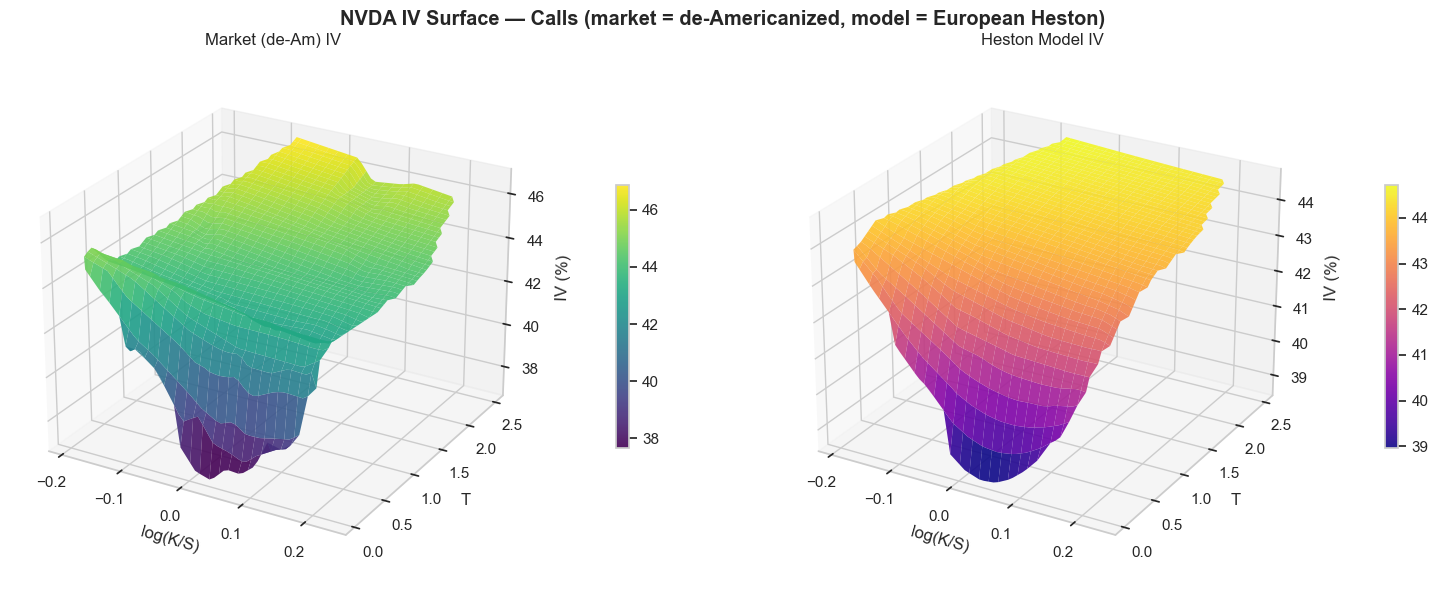

In [157]:
surf = df[(df['type'] == 'call') & df['market_iv'].notna() & df['model_iv'].notna()
          & (df['market_iv'] > 0.05)].copy()
surf['log_m'] = np.log(surf['moneyness'])
lm = np.linspace(surf['log_m'].min(), surf['log_m'].max(), 55)
Tg = np.linspace(surf['T'].min(), surf['T'].max(), 45)
LM, TT = np.meshgrid(lm, Tg)
Z_mkt = griddata((surf['log_m'], surf['T']), surf['market_iv']*100, (LM, TT), method='linear')
Z_mdl = griddata((surf['log_m'], surf['T']), surf['model_iv']*100,  (LM, TT), method='linear')

fig = plt.figure(figsize=(16, 6))
fig.suptitle(f'{TICKER} IV Surface — Calls (market = de-Americanized, model = European Heston)',
             fontweight='bold')
for i, (Z, t, cm) in enumerate([(Z_mkt,'Market (de-Am) IV','viridis'),
                                (Z_mdl,'Heston Model IV','plasma')], 1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    sp = ax.plot_surface(LM, TT, Z, cmap=cm, alpha=0.9, linewidth=0)
    ax.set_xlabel('log(K/S)'); ax.set_ylabel('T'); ax.set_zlabel('IV (%)')
    ax.set_title(t); ax.view_init(elev=25, azim=-60)
    plt.colorbar(sp, ax=ax, shrink=0.5, pad=0.1)
plt.tight_layout(); plt.show()

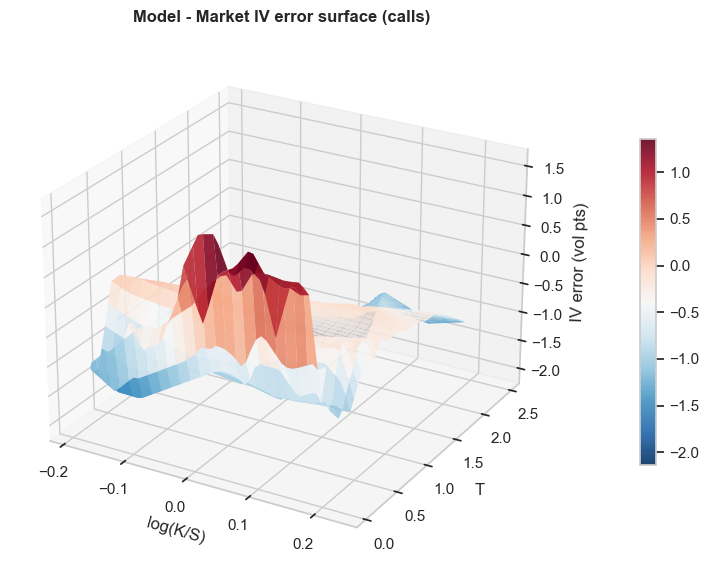

In [158]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
sp = ax.plot_surface(LM, TT, Z_mdl - Z_mkt, cmap='RdBu_r', alpha=0.9, linewidth=0)
ax.set_xlabel('log(K/S)'); ax.set_ylabel('T'); ax.set_zlabel('IV error (vol pts)')
ax.set_title('Model - Market IV error surface (calls)', fontweight='bold')
ax.view_init(elev=25, azim=-60); plt.colorbar(sp, ax=ax, shrink=0.6, pad=0.1)
plt.tight_layout(); plt.show()

## Step 7 — Mispricing  (Mispricing Screener page)

Ranked by the analytics `mispricing_score` / `iv_error` (model vs de-Americanized
market, European-equivalent). `mispricing_bias`: buy = market cheap vs model, sell = rich.

In [159]:
SHOW = ['type','maturity','strike','T','euro_mid','model_price',
        'market_iv','model_iv','iv_error','mispricing_bias']
liq = df[df['mispricing_score'].notna()].copy()
print('Top 8 — market CHEAP vs model (iv_error > 0 -> buy):')
print(liq.nlargest(8, 'iv_error')[SHOW].to_string(index=False))
print()
print('Top 8 — market RICH vs model (iv_error < 0 -> sell):')
print(liq.nsmallest(8, 'iv_error')[SHOW].to_string(index=False))

Top 8 — market CHEAP vs model (iv_error > 0 -> buy):
type   maturity   strike      T  euro_mid  model_price  market_iv  model_iv  iv_error mispricing_bias
 put 2026-07-10 195.0000 0.0372    6.2968       6.6498     0.3629    0.3867    0.0238             buy
call 2026-07-17 205.0000 0.0564    2.6298       2.9603     0.3665    0.3881    0.0216             buy
 put 2026-07-17 195.0000 0.0564    7.5437       7.9162     0.3693    0.3897    0.0204             buy
call 2026-07-10 200.0000 0.0372    2.8467       3.0777     0.3681    0.3852    0.0171             buy
call 2026-07-24 210.0000 0.0755    2.5619       2.8327     0.3753    0.3918    0.0165             buy
call 2026-07-10 195.0000 0.0372    4.7198       4.9633     0.3703    0.3867    0.0165             buy
 put 2028-12-15 220.0000 2.4728   55.8323      57.6810     0.4291    0.4452    0.0161             buy
call 2026-07-24 220.0000 0.0755    1.1684       1.3428     0.3811    0.3968    0.0157             buy

Top 8 — market RICH vs model

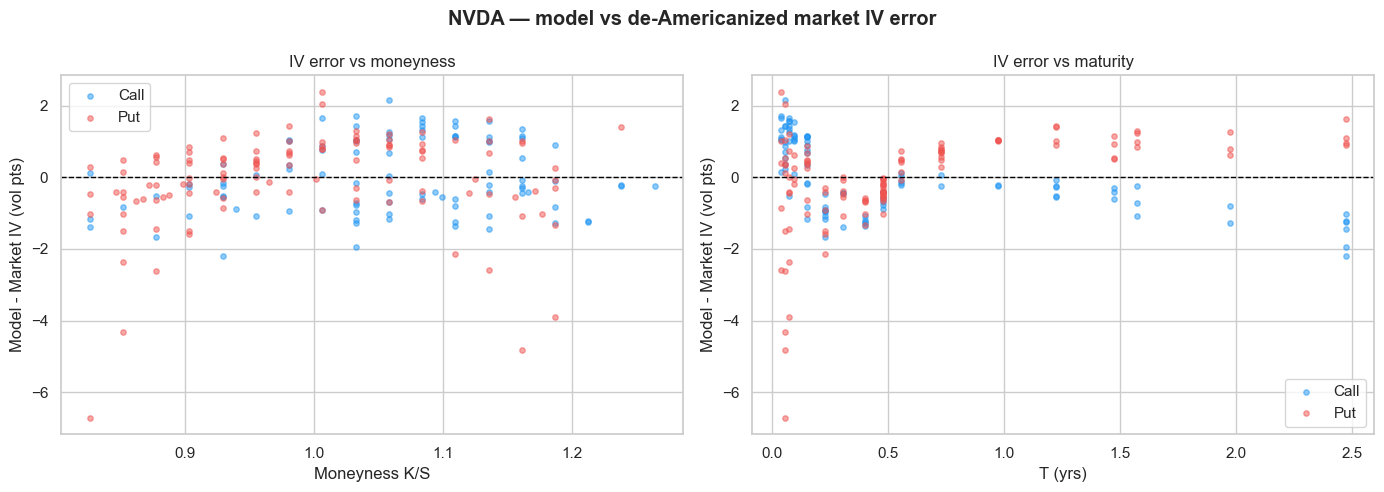

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{TICKER} — model vs de-Americanized market IV error', fontweight='bold')
for ax, x, xl in [(axes[0],'moneyness','Moneyness K/S'), (axes[1],'T','T (yrs)')]:
    for typ, c in [('call','#2196F3'), ('put','#EF5350')]:
        s = df[df.type == typ]
        ax.scatter(s[x], s['iv_error']*100, s=15, alpha=0.5, color=c, label=typ.capitalize())
    ax.axhline(0, color='black', lw=1, ls='--'); ax.set_xlabel(xl)
    ax.set_ylabel('Model - Market IV (vol pts)'); ax.legend()
axes[0].set_title('IV error vs moneyness'); axes[1].set_title('IV error vs maturity')
plt.tight_layout(); plt.show()

## Summary

In [161]:
print('=' * 60)
print(f'  {TICKER} HESTON PIPELINE (as in the app)')
print('=' * 60)
print(f'  Spot ${SPOT:.2f} | div {Q*100:.3f}% | rate {curve_summary(rate_curve)}')
print(f'  Contracts: {len(raw_df):,} raw -> {len(filtered_df):,} filtered')
print()
print(f'  Calibration (de-Americanized CF, LM)')
print(f'    v0={p.v0:.4f}  kappa={p.kappa:.4f}  theta={p.theta:.4f}  '
      f'sigma={p.sigma:.4f}  rho={p.rho:+.4f}')
print(f'    Feller {feller:+.4f}  | loss {res_cal.loss:.3e} | {res_cal.runtime_seconds:.1f}s')
print()
print(f'  Pricing/analytics (European Heston model vs de-Am market)')
print(f'    MAE ${df["abs_error"].mean():.4f} | mean |IV err| {df["iv_error"].abs().mean()*100:.2f} vpts')
print('=' * 60)

  NVDA HESTON PIPELINE (as in the app)
  Spot $193.77 | div 0.145% | rate 3M: 3.67%  |  5Y: 4.14%  |  10Y: 4.39%
  Contracts: 3,237 raw -> 209 filtered

  Calibration (de-Americanized CF, LM)
    v0=0.1474  kappa=10.0000  theta=0.2061  sigma=1.6941  rho=-0.1340
    Feller +1.2523  | loss 2.761e+01 | 1.6s

  Pricing/analytics (European Heston model vs de-Am market)
    MAE $0.3531 | mean |IV err| 0.89 vpts
